In [2]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel("/Users/esther/PycharmProjects/ad_proteomic_clock/training_data/JPST003472.xlsx").set_index("sample_id")

In [4]:
timepoint = pd.Series(data.index.str.split('_').str[0], index=data.index)

# Step-wise comparisons
step_pairs = [('3M', '5M'), ('5M', '8M'), ('8M', '14M'), ('14M', '20M'), ('20M', '26M')]

step_results = {}

for t1, t2 in step_pairs:
    d1 = data.loc[timepoint[timepoint == t1].index]
    d2 = data.loc[timepoint[timepoint == t2].index]

    p_values, log_fc = [], []
    for protein in data.columns:
        stat, p = ttest_ind(d2[protein], d1[protein], equal_var=False)
        p_values.append(p)
        log_fc.append(d2[protein].mean() - d1[protein].mean())

    step_results[f'{t1}_to_{t2}'] = pd.DataFrame({'protein': data.columns, 'p_value': p_values, 'logFC': log_fc}).set_index('protein')

    n_sig = (step_results[f'{t1}_to_{t2}']['p_value'] < 0.05).sum()

In [7]:
# Output trajectory information into table (all following code is adapted from Clause, using prior code from 3M trajectory analysis)
step_labels = [f'{t1}_to_{t2}' for t1, t2 in step_pairs]

step_logfc_matrix = pd.DataFrame({s: step_results[s]['logFC'] for s in step_labels})
step_pval_matrix = pd.DataFrame({s: step_results[s]['p_value'] for s in step_labels})

step_sig_mask = step_pval_matrix < 0.05
step_n_significant = step_sig_mask.sum(axis=1)

step_sig_proteins = step_n_significant[step_n_significant > 0].index
print(f"{len(step_sig_proteins)} proteins significant in >=1 adjacent-step comparison")

def classify_trajectory(row_mask):
    sig_indices = [i for i, v in enumerate(row_mask) if v]
    if len(sig_indices) == 0:
        return 'never'
    if len(sig_indices) == len(row_mask):
        return 'always'
    is_contiguous = sig_indices == list(range(sig_indices[0], sig_indices[-1] + 1))
    if not is_contiguous:
        return 'intermittent'
    if sig_indices[0] == 0:
        return 'early_then_drop'
    elif sig_indices[-1] == len(row_mask) - 1:
        return 'late_onset'
    else:
        return 'transient'

step_patterns = step_sig_mask.loc[step_sig_proteins, step_labels].apply(
    lambda row: classify_trajectory(row.tolist()), axis=1
)

step_combined = pd.DataFrame(index=step_sig_proteins)
step_combined['n_significant'] = step_n_significant[step_sig_proteins]
step_combined['pattern'] = step_patterns

for s in step_labels:
    step_combined[f'logFC_{s}'] = step_logfc_matrix.loc[step_sig_proteins, s]
    step_combined[f'pval_{s}'] = step_pval_matrix.loc[step_sig_proteins, s]

pattern_order = ['always', 'late_onset', 'early_then_drop',
                  'transient', 'intermittent']
step_combined['pattern'] = pd.Categorical(step_combined['pattern'], categories=pattern_order, ordered=True)
step_combined = step_combined.sort_values(['pattern', 'n_significant'], ascending=[True, False])

print(step_combined['pattern'].value_counts())
print(step_combined.head(10))

487 proteins significant in >=1 adjacent-step comparison
pattern
transient          187
early_then_drop    164
late_onset         119
intermittent        17
always               0
Name: count, dtype: int64
         n_significant     pattern  logFC_3M_to_5M  pval_3M_to_5M  \
protein                                                             
P80318               2  late_onset       -0.169231       0.187541   
Q6PDI5               2  late_onset       -0.105588       0.668771   
Q8BH60               2  late_onset        0.135611       0.149164   
Q8C0D5               2  late_onset        0.324453       0.279630   
A2A699               1  late_onset       -0.101277       0.535730   
O35459               1  late_onset       -0.307135       0.483103   
O35465               1  late_onset       -0.051426       0.799335   
O35680               1  late_onset        0.105457       0.771713   
O54829               1  late_onset        0.023617       0.909747   
O70325               1  late_onset 

In [8]:
# Save to Excel
with pd.ExcelWriter("/Users/esther/PycharmProjects/ad_proteomic_clock/results/step_trajectory.xlsx") as writer:
    for s in step_labels:
        step_results[s].sort_values('p_value').to_excel(writer, sheet_name=s[:31])
    step_combined.to_excel(writer, sheet_name="step_trajectory_ranked")

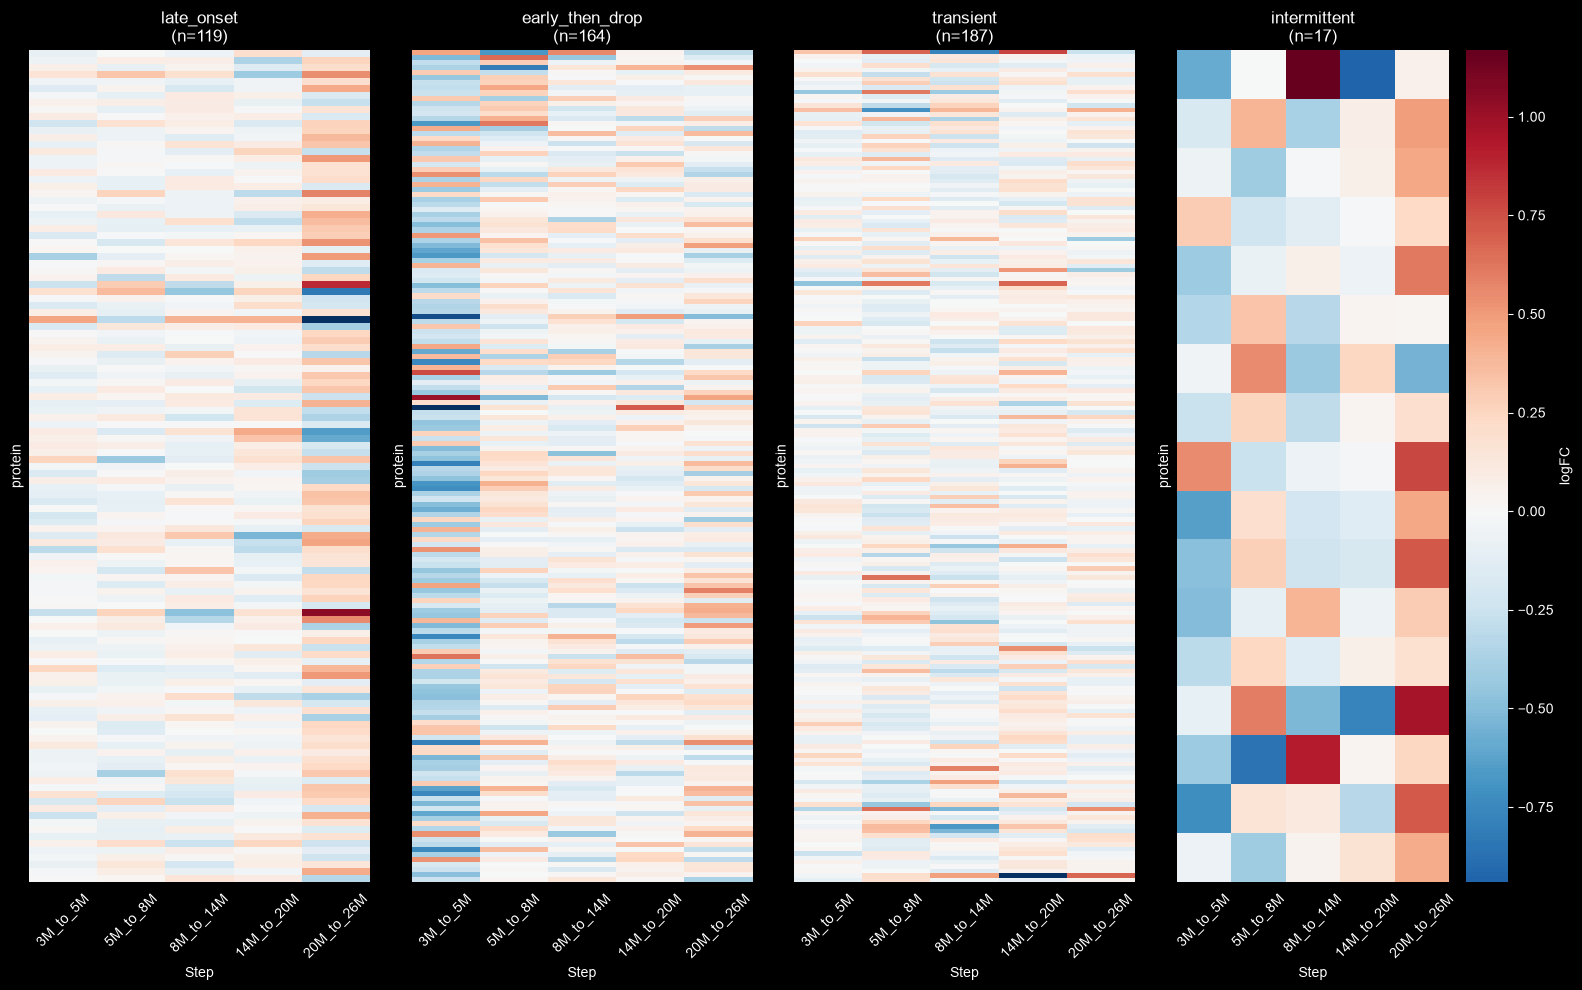

In [9]:
# Heatmap by pattern
logfc_cols = [f'logFC_{s}' for s in step_labels]
patterns_present = [p for p in pattern_order if p in step_combined['pattern'].unique()]

fig, axes = plt.subplots(1, len(patterns_present), figsize=(4 * len(patterns_present), 10))
if len(patterns_present) == 1:
    axes = [axes]

for ax, pattern in zip(axes, patterns_present):
    subset = step_combined[step_combined['pattern'] == pattern]
    hm = subset[logfc_cols].copy()
    hm.columns = step_labels
    sns.heatmap(hm, cmap='RdBu_r', center=0, cbar=(ax == axes[-1]),
                cbar_kws={'label': 'logFC'}, yticklabels=False, ax=ax)
    ax.set_title(f'{pattern}\n(n={len(subset)})')
    ax.set_xlabel('Step')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()